In [ ]:
# ============================================================
# CELL 1: Install Dependencies + Import Libraries
# ============================================================
import subprocess
import sys

def install_if_missing(package, import_name=None):
    """Install package jika belum tersedia."""
    import_name = import_name or package
    try:
        __import__(import_name)
        print(f"[OK] {package} sudah ter-install")
    except ImportError:
        print(f"[INSTALL] Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"[OK] {package} berhasil di-install")

# Install dependencies
install_if_missing("wfdb")
install_if_missing("PyWavelets", "pywt")
install_if_missing("scipy")
install_if_missing("scikit-learn", "sklearn")
install_if_missing("tensorflow")

import os
import gc
import shutil
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
import wfdb
from pathlib import Path
from collections import Counter
import ast
from datetime import datetime

# TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Cleanup
gc.collect()

print("=" * 60)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"NumPy version: {np.__version__}")
print("=" * 60)

[OK] wfdb sudah ter-install
[OK] PyWavelets sudah ter-install
[OK] scipy sudah ter-install
[OK] scikit-learn sudah ter-install
[OK] tensorflow sudah ter-install
TensorFlow version: 2.20.0
GPU available: True
NumPy version: 2.0.2


In [ ]:
# ============================================================
# CELL 2: Mount Drive, Copy ZIP, dan Unzip Dataset
# ============================================================
print("=" * 60)
print("DATA PREPARATION: MOUNT DRIVE → COPY → UNZIP")
print("=" * 60)

# --- Konfigurasi Path ---
DRIVE_MOUNT_POINT = "/content/drive"
ZIP_SOURCE_PATH = Path("/content/drive/MyDrive/dataset_echonet/ptb_xl_dataset.zip")
LOCAL_ZIP_PATH = Path("/content/ptb_xl_dataset.zip")
EXTRACT_DIR = Path("/content/ptb_xl_dataset")

# --- Step 1: Mount Google Drive ---
print("\n[Step 1/3] Mounting Google Drive...")
from google.colab import drive

if os.path.exists(DRIVE_MOUNT_POINT + "/MyDrive"):
    print("[OK] Google Drive sudah ter-mount")
else:
    print("[INFO] Mounting Google Drive...")
    drive.mount(DRIVE_MOUNT_POINT)
    print("[OK] Google Drive berhasil di-mount")

# --- Step 2: Copy ZIP dari Drive ke Disk Lokal Colab ---
print("\n[Step 2/3] Copy ZIP dari Drive ke disk lokal...")
if not ZIP_SOURCE_PATH.exists():
    print(f"[ERROR] File tidak ditemukan: {ZIP_SOURCE_PATH}")
    print("[DEBUG] Isi folder dataset_echonet:")
    drive_folder = Path("/content/drive/MyDrive/dataset_echonet")
    if drive_folder.exists():
        for item in sorted(drive_folder.iterdir()):
            print(f"  - {item.name} ({'dir' if item.is_dir() else 'file'})")
else:
    if LOCAL_ZIP_PATH.exists():
        print(f"[OK] ZIP sudah ada di disk lokal: {LOCAL_ZIP_PATH}")
    else:
        print(f"[INFO] Copying {ZIP_SOURCE_PATH.name} ke {LOCAL_ZIP_PATH}...")
        start_time = datetime.now()
        shutil.copy2(ZIP_SOURCE_PATH, LOCAL_ZIP_PATH)
        elapsed = (datetime.now() - start_time).total_seconds()
        size_mb = LOCAL_ZIP_PATH.stat().st_size / (1024 * 1024)
        print(f"[OK] Copy selesai dalam {elapsed:.1f} detik")
        print(f"     Ukuran: {size_mb:.2f} MB")

# --- Step 3: Unzip ke Disk Lokal ---
print("\n[Step 3/3] Unzipping dataset...")
if EXTRACT_DIR.exists() and any(EXTRACT_DIR.iterdir()):
    print(f"[OK] Dataset sudah di-extract: {EXTRACT_DIR}")
else:
    print(f"[INFO] Extracting ke {EXTRACT_DIR}...")
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    start_time = datetime.now()

    with zipfile.ZipFile(LOCAL_ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)

    elapsed = (datetime.now() - start_time).total_seconds()
    print(f"[OK] Unzip selesai dalam {elapsed:.1f} detik")

# --- Verifikasi ---
print("\n[VERIFIKASI]")
print(f"  Extract dir: {EXTRACT_DIR}")
if EXTRACT_DIR.exists():
    # Cek struktur
    subdirs = [d for d in EXTRACT_DIR.iterdir() if d.is_dir()]
    print(f"  Subdirectories: {len(subdirs)}")
    for d in subdirs[:3]:
        print(f"    - {d.name}")

    # Cari folder dataset utama (biasanya ada nama versi)
    dataset_root = None
    for d in subdirs:
        if "ptb-xl" in d.name.lower():
            dataset_root = d
            break

    if dataset_root:
        print(f"\n  Dataset root: {dataset_root}")
        csv_files = list(dataset_root.glob("*.csv"))
        print(f"  CSV files: {len(csv_files)}")
        for csv in csv_files:
            print(f"    - {csv.name}")

print("\n" + "=" * 60)
print("DATA PREPARATION SELESAI!")
print("=" * 60)

DATA PREPARATION: MOUNT DRIVE → COPY → UNZIP

[Step 1/3] Mounting Google Drive...
[OK] Google Drive sudah ter-mount

[Step 2/3] Copy ZIP dari Drive ke disk lokal...
[OK] ZIP sudah ada di disk lokal: /content/ptb_xl_dataset.zip

[Step 3/3] Unzipping dataset...
[OK] Dataset sudah di-extract: /content/ptb_xl_dataset

[VERIFIKASI]
  Extract dir: /content/ptb_xl_dataset
  Subdirectories: 1
    - ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3

  Dataset root: /content/ptb_xl_dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3
  CSV files: 2
    - ptbxl_database.csv
    - scp_statements.csv

DATA PREPARATION SELESAI!


In [ ]:
# ============================================================
# CELL 3: Konfigurasi & Hyperparameters
# ============================================================
print("=" * 60)
print("KONFIGURASI TRAINING")
print("=" * 60)

# --- Paths (Auto-detect dataset root) ---
EXTRACT_DIR = Path("/content/ptb_xl_dataset")
dataset_root = None
for d in EXTRACT_DIR.iterdir():
    if d.is_dir() and "ptb-xl" in d.name.lower():
        dataset_root = d
        break

if dataset_root is None:
    dataset_root = next(EXTRACT_DIR.iterdir())

PTBXL_DIR = dataset_root
METADATA_CSV = PTBXL_DIR / "ptbxl_database.csv"
SCP_STATEMENTS_CSV = PTBXL_DIR / "scp_statements.csv"

print(f"Dataset root: {PTBXL_DIR}")
print(f"Metadata CSV exists: {METADATA_CSV.exists()}")

# --- Model Configuration ---
CONFIG = {
    # Data
    "max_samples": 2500,         # ⬆️ naikkan dari 600 → 2000 (masih aman utk RAM)
    "test_size": 0.2,

    # ECG Signal
    "sampling_rate": 100,
    "signal_length": 1000,
    "selected_leads": ["II", "V2", "V5"],
    "lead_indices": {},

    # CWT
    "wavelet": "morl",
    "scales": np.arange(1, 32),  # ⬇️ kurangi dari 64 → 32 (hemat RAM & waktu)
    "cwt_output_size": 224,

    # Training
    "batch_size": 16,            # ⬆️ naikkan dari 8 → 16
    "epochs": 50,                # ⬆️ naikkan dari 6 → 15
    "learning_rate": 1e-3,       # ⬆️ naikkan dari 1e-4 → 1e-3 (head-only butuh LR besar)

    # Model
    "input_shape": (224, 224, 3),
    "dropout_rate": 0.4,
    "num_classes": 1,

    # Cache
    "cache_dir": Path("/content/.ptbxl_cache"),
}

CONFIG["cache_dir"].mkdir(parents=True, exist_ok=True)

for key, value in CONFIG.items():
    if key not in ["scales", "cache_dir"]:
        print(f"  {key:25s}: {value}")

print("=" * 60)

KONFIGURASI TRAINING
Dataset root: /content/ptb_xl_dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3
Metadata CSV exists: True
  max_samples              : 2500
  test_size                : 0.2
  sampling_rate            : 100
  signal_length            : 1000
  selected_leads           : ['II', 'V2', 'V5']
  lead_indices             : {}
  wavelet                  : morl
  cwt_output_size          : 224
  batch_size               : 16
  epochs                   : 50
  learning_rate            : 0.001
  input_shape              : (224, 224, 3)
  dropout_rate             : 0.4
  num_classes              : 1


In [ ]:
# ============================================================
# CELL 4: Label Mapping (SCP Codes → HF / Non-HF)
# ============================================================
print("=" * 60)
print("MAPPING SCP CODES → LABEL")
print("=" * 60)

# Load metadata
df_meta = pd.read_csv(METADATA_CSV)
df_scp = pd.read_csv(SCP_STATEMENTS_CSV)

print(f"Total records: {len(df_meta)}")

# Buat mapping SCP code → diagnostic_class
scp_to_class = dict(zip(df_scp["Unnamed: 0"], df_scp["diagnostic_class"]))
print(f"\nSCP → Class mapping count: {len(scp_to_class)}")

# --- Strategi Mapping ---
HF_CLASSES = {"MI", "HYP", "CD"}
NON_HF_CLASSES = {"NORM"}
EXCLUDE_CLASSES = {"STTC"}

def parse_scp_codes(scp_string):
    try:
        scp_dict = ast.literal_eval(scp_string)
        codes = [k for k, v in scp_dict.items() if v > 0]
        return codes
    except:
        return []

def get_label_from_scp(scp_codes):
    if not scp_codes:
        return None

    classes = set()
    for code in scp_codes:
        if code in scp_to_class:
            classes.add(scp_to_class[code])

    has_hf = bool(classes & HF_CLASSES)
    has_non_hf = bool(classes & NON_HF_CLASSES)
    has_exclude = bool(classes & EXCLUDE_CLASSES)

    if has_hf and not has_exclude:
        return 1  # HF
    elif has_non_hf and not has_hf and not has_exclude:
        return 0  # Non-HF
    else:
        return None

print("\nApplying labels...")
df_meta["parsed_scp"] = df_meta["scp_codes"].apply(parse_scp_codes)
df_meta["label"] = df_meta["parsed_scp"].apply(get_label_from_scp)

df_labeled = df_meta[df_meta["label"].notna()].copy()
df_labeled["label"] = df_labeled["label"].astype(int)

print(f"\n{'Label':<10} {'Count':<10} {'Percentage':<12}")
print("-" * 32)
label_counts = df_labeled["label"].value_counts()
for label, count in label_counts.items():
    pct = count / len(df_labeled) * 100
    label_name = "HF" if label == 1 else "Non-HF"
    print(f"{label_name:<10} {count:<10} {pct:.1f}%")

# Subset untuk testing
np.random.seed(42)
hf_samples = df_labeled[df_labeled["label"] == 1].sample(
    n=min(CONFIG["max_samples"] // 2, label_counts.get(1, 0)),
    random_state=42
)
non_hf_samples = df_labeled[df_labeled["label"] == 0].sample(
    n=min(CONFIG["max_samples"] // 2, label_counts.get(0, 0)),
    random_state=42
)
df_subset = pd.concat([hf_samples, non_hf_samples]).sample(frac=1, random_state=42)

print(f"\nSubset size untuk training: {len(df_subset)}")
print(f"Distribution di subset: {df_subset['label'].value_counts().to_dict()}")

del df_meta, df_scp, df_labeled, hf_samples, non_hf_samples
gc.collect()

print("=" * 60)

MAPPING SCP CODES → LABEL
Total records: 21799

SCP → Class mapping count: 71

Applying labels...

Label      Count      Percentage  
--------------------------------
Non-HF     9097       55.9%
HF         7170       44.1%

Subset size untuk training: 2500
Distribution di subset: {0: 1250, 1: 1250}


In [ ]:
# ============================================================
# CELL 5: CWT & Preprocessing Functions
# ============================================================
print("=" * 60)
print("CWT & PREPROCESSING FUNCTIONS")
print("=" * 60)

def load_ecg_signal(filename_lr):
    filepath = PTBXL_DIR / filename_lr
    try:
        record = wfdb.rdrecord(str(filepath), physical=True)
        signals = record.p_signal
        lead_names = record.sig_name
        return {lead: signals[:, i] for i, lead in enumerate(lead_names)}
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def standardize_signal(signal):
    """Z-score standardization per lead SEBELUM CWT."""
    mean = np.mean(signal)
    std = np.std(signal)
    if std < 1e-8:
        return signal - mean
    return (signal - mean) / std

def apply_cwt(signal, wavelet="morl", scales=None):
    if scales is None:
        scales = np.arange(1, 32)
    coefficients, frequencies = pywt.cwt(signal, scales, wavelet)
    scalogram = np.abs(coefficients)
    return scalogram

def normalize_scalogram(scalogram):
    """Min-max normalize ke [0, 1]."""
    min_val = scalogram.min()
    max_val = scalogram.max()
    if max_val - min_val > 1e-8:
        return (scalogram - min_val) / (max_val - min_val)
    return scalogram

def resize_array(arr, target_size=224):
    from PIL import Image
    img = Image.fromarray(arr.astype(np.float32))
    img_resized = img.resize((target_size, target_size), Image.BILINEAR)
    return np.array(img_resized)

def process_single_ecg(filename_lr, selected_leads, config):
    signals_dict = load_ecg_signal(filename_lr)
    if signals_dict is None:
        return None

    lead_scalograms = []
    for lead in selected_leads:
        if lead not in signals_dict:
            lead_alt = lead.upper() if lead.islower() else lead.lower()
            if lead_alt in signals_dict:
                lead = lead_alt
            else:
                return None

        signal = signals_dict[lead]

        if len(signal) != config["signal_length"]:
            if len(signal) > config["signal_length"]:
                signal = signal[:config["signal_length"]]
            else:
                signal = np.pad(signal, (0, config["signal_length"] - len(signal)))

        # ✅ TAMBAHAN: standardisasi signal sebelum CWT
        signal = standardize_signal(signal)

        scalogram = apply_cwt(signal, config["wavelet"], config["scales"])
        scalogram = normalize_scalogram(scalogram)
        scalogram_resized = resize_array(scalogram, config["cwt_output_size"])
        lead_scalograms.append(scalogram_resized)

    image = np.stack(lead_scalograms, axis=-1).astype(np.float32)
    return image

# Test
print("Testing CWT pipeline dengan 1 sample...")
test_row = df_subset.iloc[0]
test_img = process_single_ecg(
    test_row["filename_lr"],
    CONFIG["selected_leads"],
    CONFIG,
)

if test_img is not None:
    print(f"✓ Success! Output shape: {test_img.shape}")
    print(f"  Min: {test_img.min():.3f}, Max: {test_img.max():.3f}")
else:
    print("✗ Test gagal")

print("=" * 60)

CWT & PREPROCESSING FUNCTIONS
Testing CWT pipeline dengan 1 sample...
✓ Success! Output shape: (224, 224, 3)
  Min: 0.000, Max: 0.949


In [ ]:
# ============================================================
# CELL 6: Data Generator (RAM-Friendly)
# ============================================================
print("=" * 60)
print("DATA GENERATOR (LAZY LOADING)")
print("=" * 60)

class PTBXLECGGenerator(tf.keras.utils.Sequence):
    def __init__(self, dataframe, config, batch_size=16, shuffle=True, augment=False):
        super().__init__()  # ✅ FIX: panggil super() agar warning hilang
        self.df = dataframe.reset_index(drop=True)
        self.config = config
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.indices = np.arange(len(self.df))

        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        # ✅ FIX: gunakan SEMUA data, bukan dibatasi steps_per_epoch
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_X = []
        batch_y = []

        for i in batch_indices:
            row = self.df.iloc[i]
            filename = row["filename_lr"]
            label = row["label"]

            img = process_single_ecg(
                filename,
                self.config["selected_leads"],
                self.config,
            )

            if img is not None:
                # ✅ TAMBAHAN: augmentasi ringan untuk training
                if self.augment and np.random.random() > 0.5:
                    noise = np.random.normal(0, 0.02, img.shape).astype(np.float32)
                    img = np.clip(img + noise, 0.0, 1.0)

                batch_X.append(img)
                batch_y.append(label)

        X = np.array(batch_X, dtype=np.float32)
        y = np.array(batch_y, dtype=np.float32)

        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# Split
train_df, val_df = train_test_split(
    df_subset,
    test_size=CONFIG["test_size"],
    random_state=42,
    stratify=df_subset["label"]
)

print(f"Train size: {len(train_df)}")
print(f"Val size:   {len(val_df)}")

train_generator = PTBXLECGGenerator(
    train_df, CONFIG,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    augment=True      # ✅ augmentasi hanya untuk training
)
val_generator = PTBXLECGGenerator(
    val_df, CONFIG,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    augment=False
)

print(f"\nTrain generator: {len(train_generator)} batches/epoch")
print(f"Val generator:   {len(val_generator)} batches/epoch")

print("\nTesting 1 batch...")
X_test, y_test = train_generator[0]
print(f"  X shape: {X_test.shape}")
print(f"  y shape: {y_test.shape}")

del df_subset
gc.collect()

print("=" * 60)

DATA GENERATOR (LAZY LOADING)
Train size: 2000
Val size:   500

Train generator: 125 batches/epoch
Val generator:   32 batches/epoch

Testing 1 batch...
  X shape: (16, 224, 224, 3)
  y shape: (16,)


In [ ]:
# ============================================================
# CELL 7: Build Model - EfficientNetV2B0
# ============================================================
print("=" * 60)
print("BUILD MODEL: EfficientNetV2B0")
print("=" * 60)

def build_hf_classifier(config):
    base_model = EfficientNetV2B0(
        input_shape=config["input_shape"],
        include_top=False,
        weights="imagenet",
        pooling="avg"
    )

    # ✅ FIX: unfreeze sebagian layer akhir base model
    # Base model punya ~100+ layer, unfreeze 20 layer terakhir
    base_model.trainable = True
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    inputs = keras.Input(shape=config["input_shape"])
    x = base_model(inputs, training=False)

    # ✅ Sederhanakan head (data sedikit → jangan terlalu kompleks)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(config["dropout_rate"])(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)
    return model

model = build_hf_classifier(CONFIG)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CONFIG["learning_rate"]),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc"),
        keras.metrics.Recall(name="sensitivity"),
        keras.metrics.Precision(name="precision"),
    ]
)

model.summary()

# Cek berapa parameter yang trainable
trainable_count = sum(1 for l in model.layers if l.trainable)
print(f"\nTrainable layers: {trainable_count}")
print("=" * 60)

BUILD MODEL: EfficientNetV2B0


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 1280)           │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,083,409 (23.21 MB)

 Trainable params: 1,317,601 (5.03 MB)

 Non-trainable params: 4,765,808 (18.18 MB)


Trainable layers: 5


In [ ]:
# ============================================================
# CELL 8: Class Weights
# ============================================================
print("=" * 60)
print("CLASS WEIGHTS COMPUTATION")
print("=" * 60)

y_train_all = train_df["label"].values
classes = np.unique(y_train_all)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_all
)
class_weights_dict = dict(zip(classes, class_weights_array))

print("\nClass distribution:")
for cls, weight in class_weights_dict.items():
    count = np.sum(y_train_all == cls)
    pct = count / len(y_train_all) * 100
    label_name = "HF" if cls == 1 else "Non-HF"
    print(f"  {label_name}: {count} samples ({pct:.1f}%) → weight: {weight:.3f}")

del y_train_all
gc.collect()

print("=" * 60)

CLASS WEIGHTS COMPUTATION

Class distribution:
  Non-HF: 1000 samples (50.0%) → weight: 1.000
  HF: 1000 samples (50.0%) → weight: 1.000


In [ ]:
# ============================================================
# CELL 9: Training
# ============================================================
print("=" * 60)
print("TRAINING")
print("=" * 60)

callbacks = [
    EarlyStopping(
        monitor="val_auc",          # ✅ FIX: pantau AUC, bukan val_loss
        patience=5,                 # ⬆️ naikkan dari 2 → 5
        restore_best_weights=True,
        mode="max",                 # ✅ AUC: semakin besar semakin baik
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.5,
        patience=3,                 # ⬆️ naikkan dari 1 → 3
        min_lr=1e-6,
        mode="max",
        verbose=1
    ),
    ModelCheckpoint(
        str(CONFIG["cache_dir"] / "best_model_ptbxl.keras"),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
]

print(f"\nStarting training...")
print(f"  Epochs: {CONFIG['epochs']}")
print(f"  Train batches/epoch: {len(train_generator)}")
print(f"  Val batches: {len(val_generator)}")

history = model.fit(
    train_generator,
    epochs=CONFIG["epochs"],
    # ✅ HAPUS steps_per_epoch → pakai semua data
    validation_data=val_generator,
    # ✅ HAPUS validation_steps → pakai semua data val
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining selesai!")

gc.collect()
print("=" * 60)

TRAINING

Starting training...
  Epochs: 50
  Train batches/epoch: 125
  Val batches: 32
Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.5101 - auc: 0.5106 - loss: 0.7435 - precision: 0.4993 - sensitivity: 0.5044
Epoch 1: val_auc improved from None to 0.62499, saving model to /content/.ptbxl_cache/best_model_ptbxl.keras

Epoch 1: finished saving model to /content/.ptbxl_cache/best_model_ptbxl.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 121s 698ms/step - accuracy: 0.5120 - auc: 0.5167 - loss: 0.7261 - precision: 0.5115 - sensitivity: 0.5320 - val_accuracy: 0.5000 - val_auc: 0.6250 - val_loss: 0.6929 - val_precision: 0.0000e+00 - val_sensitivity: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.5081 - auc: 0.5099 - loss: 0.7021 - precision: 0.4935 - sensitivity: 0.4131
Epoch 2: val_auc did not improve from 0.62499
125/125 ━━━━━━━━━━━━━━━━━━━━ 66s 532ms/step - accuracy: 0.5165 - auc: 0.5178 - loss: 0.7007 - precision: 0.5189

HASIL TRAINING & SAVE MODEL


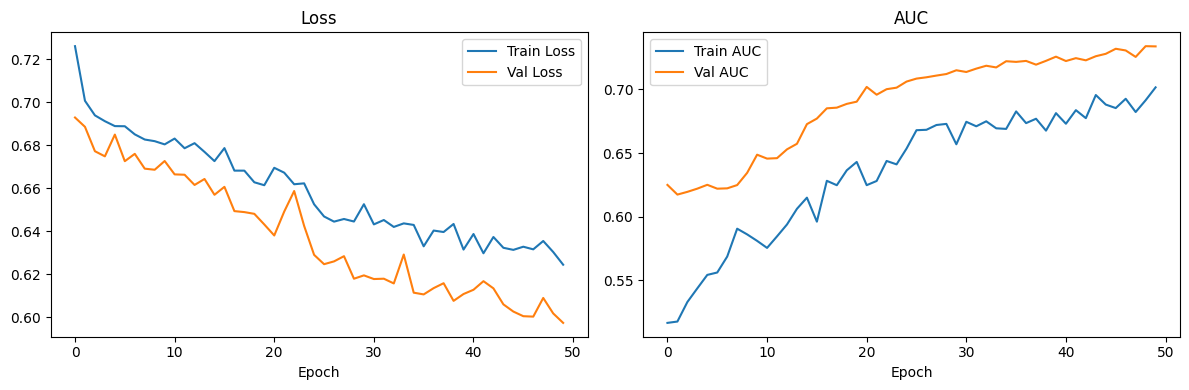


Final Training Metrics:
  accuracy            : 0.6470
  auc                 : 0.7015
  loss                : 0.6245
  precision           : 0.6847
  sensitivity         : 0.5450
  learning_rate       : 0.0001

Final Validation Metrics:
  val_accuracy        : 0.6560
  val_auc             : 0.7337
  val_loss            : 0.5974
  val_precision       : 0.7010
  val_sensitivity     : 0.5440

✓ Model saved ke: /content/.ptbxl_cache/final_model_ptbxl_hf_classifier.keras
✓ Class weights saved ke: /content/.ptbxl_cache/class_weights_ptbxl.json
✓ Config saved ke: /content/.ptbxl_cache/config_ptbxl.json

✓ Artifact zip dibuat: /content/.ptbxl_cache/ptbxl_model_artifacts.zip
Memulai download artifact...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download dimulai. Periksa browser Anda.
DONE! Model siap untuk deployment.


In [ ]:
# ============================================================
# CELL 10: Visualisasi, Save Model, dan Download Artifact
# ============================================================
import json
import zipfile
from pathlib import Path

print("=" * 60)
print("HASIL TRAINING & SAVE MODEL")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

if "auc" in history.history:
    axes[1].plot(history.history["auc"], label="Train AUC")
    axes[1].plot(history.history["val_auc"], label="Val AUC")
    axes[1].set_title("AUC")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

plt.tight_layout()
plt.show()

print("\nFinal Training Metrics:")
for metric, value in history.history.items():
    if not metric.startswith("val_"):
        print(f"  {metric:20s}: {value[-1]:.4f}")

print("\nFinal Validation Metrics:")
for metric, value in history.history.items():
    if metric.startswith("val_"):
        print(f"  {metric:20s}: {value[-1]:.4f}")

# ============================================================
# Simpan model dan artifact
# ============================================================
cache_dir = Path(CONFIG["cache_dir"])
cache_dir.mkdir(parents=True, exist_ok=True)

final_model_path = cache_dir / "final_model_ptbxl_hf_classifier.keras"
class_weights_path = cache_dir / "class_weights_ptbxl.json"
config_path = cache_dir / "config_ptbxl.json"

model.save(final_model_path)
print(f"\n✓ Model saved ke: {final_model_path}")

# Fix: Convert keys to standard int because json cannot serialize np.int64
serializable_weights = {
    int(k): float(v) for k, v in class_weights_dict.items()
}

with open(class_weights_path, "w") as f:
    json.dump(serializable_weights, f, indent=4)

with open(config_path, "w") as f:
    json.dump(
        {
            "selected_leads": CONFIG["selected_leads"],
            "input_shape": CONFIG["input_shape"],
            "sampling_rate": CONFIG["sampling_rate"],
        },
        f,
        indent=4,
    )

print(f"✓ Class weights saved ke: {class_weights_path}")
print(f"✓ Config saved ke: {config_path}")

# ============================================================
# Download otomatis
# ============================================================
artifact_paths = [
    final_model_path,
    class_weights_path,
    config_path,
]

zip_path = cache_dir / "ptbxl_model_artifacts.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in artifact_paths:
        zf.write(p, arcname=p.name)

print(f"\n✓ Artifact zip dibuat: {zip_path}")

try:
    from google.colab import files

    print("Memulai download artifact...")
    files.download(str(zip_path))
    print("✓ Download dimulai. Periksa browser Anda.")

except ImportError:
    print("\n[INFO] google.colab.files tidak tersedia.")
    print("Kemungkinan Anda tidak menjalankan di Google Colab.")
    print("File tetap tersimpan di:")
    for p in artifact_paths:
        print(f"  - {p.resolve()}")
    print(f"Zip artifact: {zip_path.resolve()}")

    # Opsional: tampilkan link download di Jupyter lokal jika mendukung
    try:
        from IPython.display import display, FileLink

        print("\nLink file lokal:")
        display(FileLink(str(final_model_path)))
        display(FileLink(str(class_weights_path)))
        display(FileLink(str(config_path)))
        display(FileLink(str(zip_path)))
    except Exception as e:
        print(f"Tidak dapat menampilkan FileLink: {e}")

print("=" * 60)
print("DONE! Model siap untuk deployment.")
print("=" * 60)

GENERATING CONFUSION MATRIX
Predicting on validation set...


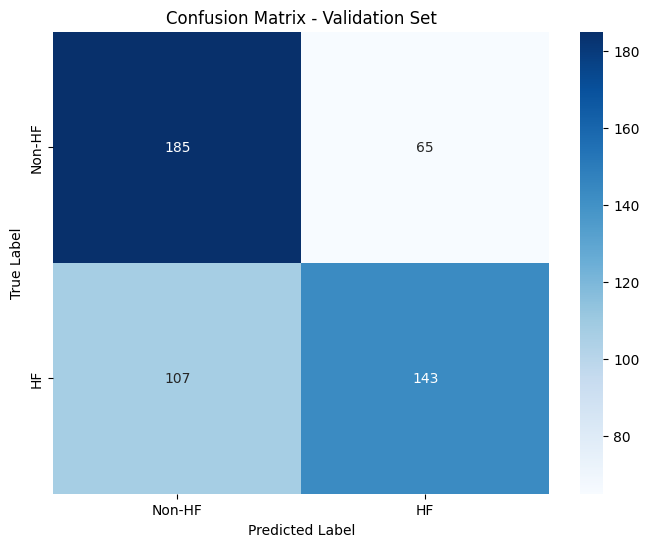


Classification Report:
              precision    recall  f1-score   support

      Non-HF       0.63      0.74      0.68       250
          HF       0.69      0.57      0.62       250

    accuracy                           0.66       500
   macro avg       0.66      0.66      0.65       500
weighted avg       0.66      0.66      0.65       500



In [ ]:
# ============================================================
# CELL 11: Confusion Matrix
# ============================================================
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("=" * 60)
print("GENERATING CONFUSION MATRIX")
print("=" * 60)

# 1. Ambil semua ground truth dan prediksi dari validation generator
y_true = []
y_pred_probs = []

print("Predicting on validation set...")
for i in range(len(val_generator)):
    X_val, y_val = val_generator[i]
    y_true.extend(y_val)
    preds = model.predict(X_val, verbose=0)
    y_pred_probs.extend(preds.flatten())

y_true = np.array(y_true)
y_pred = (np.array(y_pred_probs) > 0.5).astype(int)

# 2. Hitung Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Visualisasi dengan Seaborn Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-HF', 'HF'],
            yticklabels=['Non-HF', 'HF'])
plt.title('Confusion Matrix - Validation Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 4. Print Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Non-HF', 'HF']))
print("=" * 60)